In [1]:
%matplotlib inline
# changed from %matplotlib notebook as graphs werent being plotted 

In [20]:
from Bio.Align import PairwiseAligner, substitution_matrices
from Bio.Seq import Seq 
from Bio.SeqRecord import SeqRecord
from Bio import SeqIO
import numpy as np
from numpy import random as rd
from matplotlib import pyplot as plt
from scipy.stats import norm

import os
import pickle
from matplotlib.ticker import MaxNLocator, ScalarFormatter, FormatStrFormatter
from matplotlib.ticker import LinearLocator
FIGSIZE = (4.5,3)
DPI = 300
N_TICKS = 3

In [30]:
from src.discrimalign import discrimalign
from src.logit_link import logit_partial_scores
from src.optimization import create_powerstep, create_constant_step, get_initial_estimate

# Data

In [4]:
from miRBench.dataset import list_datasets, get_dataset_df

In [5]:
hejret_train = get_dataset_df(list_datasets()[0], split="train")
hejret_test = get_dataset_df(list_datasets()[0], split="test")

Using cached dataset /home/mciach/.miRBench/datasets/14501607/AGO2_CLASH_Hejret2023/train/dataset.tsv
Using cached dataset /home/mciach/.miRBench/datasets/14501607/AGO2_CLASH_Hejret2023/test/dataset.tsv


In [6]:
mirlist = hejret_train['noncodingRNA']
mirlist = [Seq(seq) for seq in mirlist]
genelist = hejret_train['gene']
genelist = [Seq(seq).reverse_complement() for seq in genelist]

# Optimization

### Data generation

In [279]:
subsM = np.array([[1, -0.3, -0.1, -0.8], 
                    [-0.6, 1.2, -0.3, -0.2], 
                    [-0.1, -0.4, 1, -0.3], 
                    [-0.4, -0.3, -0.2, 1.3]])
subsM /= np.sum(subsM**2)
true_gapopen = -1
true_gapext = -0.1
true_substitution = substitution_matrices.Array(alphabet='ACTG', 
                                          data=subsM)
theta_star = np.concatenate([np.array(true_substitution).flatten(), 
                             [true_gapopen, true_gapext]]) ## what we try to estimate
true_substitution

Array([[ 0.1447178 , -0.04341534, -0.01447178, -0.11577424],
       [-0.08683068,  0.17366136, -0.04341534, -0.02894356],
       [-0.01447178, -0.05788712,  0.1447178 , -0.04341534],
       [-0.05788712, -0.04341534, -0.02894356,  0.18813314]],
         alphabet='ACTG')

In [280]:
# # Random modification of the substitution matrix
# true_substitution += norm.rvs(size=true_substitution.shape, scale=0.2)
# true_substitution

In [281]:
aligner = PairwiseAligner()
aligner.mode = 'local'
aligner.open_gap_score = true_gapopen
aligner.extend_gap_score = true_gapext
aligner.substitution_matrix = true_substitution

In [282]:
# Constant values
scores = np.array([aligner.score(a, b) for a, b in zip(mirlist, genelist)])
true_alpha = -np.median(scores)
logit_scores = logit_partial_scores(scores, true_alpha)

In [283]:
# Random values
labels = rd.rand(len(mirlist))
labels = labels <= logit_scores
true_logL = np.sum(np.log(logit_scores[labels]))+np.sum(np.log(1-logit_scores[~labels]))
print('Sum of log-logit scores:', np.sum(np.log(logit_scores)))
print('True LogL:', true_logL)

Sum of log-logit scores: -5619.018378361364
True LogL: -5586.473515843274


### Baseline estimator

In [284]:
baseline_gapopen = -10
baseline_gapextend = -0.5
baseline_matrix = substitution_matrices.Array(alphabet='ACTG', 
                                          data=np.eye(4)*9 - 4)
baseline_aligner = PairwiseAligner()
baseline_aligner.mode = 'local'
baseline_aligner.open_gap_score = baseline_gapopen
baseline_aligner.extend_gap_score = baseline_gapextend
baseline_aligner.substitution_matrix = baseline_matrix

In [285]:
baseline_alignments = [next(baseline_aligner.align(A, B)) for A, B in zip(mirlist, genelist)]

In [286]:
baseline_estimate = get_initial_estimate(baseline_alignments, 
                                         labels, 
                                         substitution_mode='general', 
                                         gap_mode='affine',
                                         alphabet=true_substitution.alphabet)

In [287]:
baseline_estimate

{'alpha': -0.7900753332723883,
 'substitution_matrix': Array([[ 0.0953942 , -0.106077  , -0.03107035, -0.07117486],
        [-0.16207849,  0.11663512,  0.01678408, -0.07770272],
        [-0.08778585, -0.07904815,  0.10286485,  0.01861824],
        [-0.05549127, -0.03304228, -0.04307205,  0.12206237]],
          alphabet='ACTG'),
 'open_gap_score': -0.3116475662208236,
 'extend_gap_score': -0.007386831627582985}

In [288]:
theta_baseline = np.concatenate([np.array(baseline_estimate['substitution_matrix']).flatten(), 
                                [baseline_estimate['open_gap_score'], 
                                baseline_estimate['extend_gap_score']]])

In [289]:
np.linalg.norm(theta_baseline - theta_star)

0.7225280067808264

### DiscrimAlign

In [290]:
const_step = create_constant_step(0.00002)
powerstep = create_powerstep(0.00002, power=0.2, burnin=200) # burnin = nb of iterations with constant step
# powerstep = create_powerstep(0.00002, power=-0.1, burnin=0)

In [291]:
NITER = 1000 ## original 200 

In [292]:
params = discrimalign(mirlist, genelist, labels, 
                    stepfunction=const_step,  # NOTE WHICH STEP
                    aligner_mode='local',
                    substitution_mode='general',
                    gap_mode='affine', 
                    stochastic_factor=0.001,
                    verbose=True, max_iter=NITER,
                    num_threads = 24)

Alphabet:
ACGT
Initial parameters:
{'alpha': -0.6984121985308531, 'substitution_matrix': Array([[ 0.08069537, -0.09294664, -0.08053533, -0.04095881],
       [-0.14774231,  0.10156901, -0.14723644,  0.02992209],
       [-0.08545455, -0.07947521,  0.11217617, -0.0602446 ],
       [-0.08458048, -0.06720179, -0.02046579,  0.09391331]],
         alphabet='ACGT'), 'open_gap_score': -0.21448774466974566, 'extend_gap_score': -0.0073522919817418375}
Start of iteration 0
Current alpha: -0.6984121985308531
Current logL: -5608.586588268169
Updated alpha: -0.7824375658277581
Updated logL: -5601.467631385577
New subgradient:
{'Substitutions': Array([[-24.13293646,  15.48438546, -16.73213364,  25.08098099],
       [ -6.93922815, -47.5019665 ,  -8.11637382, -57.01423172],
       [ 36.07048037,  43.99490579,  -9.48868862,  -6.35309287],
       [ -5.361635  , -31.56683954,  12.55038826, -35.65175304]],
         alphabet='ACGT'), 'Gap opens': -132.67149775591318, 'Gap extends': -427.19017156612614}
Steps

Current alpha: -0.7303273811986504
Current logL: -5595.757433753073
Updated alpha: -0.7298653645549713
Updated logL: -5595.757218264653
New subgradient:
{'Substitutions': Array([[-10.17248807,   7.20897754, -23.02848176,  -5.5542749 ],
       [-18.39249739,  -5.54118268,   3.33353834, -31.46806876],
       [  4.83237951,  27.97907957,  13.34600746,  11.9715337 ],
       [  1.9934812 , -29.71774881, -20.53342918,  39.90222274]],
         alphabet='ACGT'), 'Gap opens': -74.88536158361127, 'Gap extends': -35.88695423010352}
Stepsize: 2e-05
Gap open step: -0.0014977072316722255
Gap extend step: -0.0007177390846020705
New parameters:
{'alpha': -0.7298653645549713, 'substitution_matrix': Array([[ 0.07930916, -0.09096223, -0.08347644, -0.04096931],
       [-0.15009191,  0.09942857, -0.14709854,  0.02237096],
       [-0.08293646, -0.07390744,  0.11573552, -0.06006396],
       [-0.08422036, -0.07132175, -0.02168611,  0.09386314]],
         alphabet='ACGT'), 'open_gap_score': -0.2305347096961474

Current alpha: -0.7351415731965344
Current logL: -5594.050929053166
Updated alpha: -0.7370322299909291
Updated logL: -5594.047322112921
New subgradient:
{'Substitutions': Array([[  0.96194461,  10.09878586, -30.12049364,  -9.57294415],
       [-16.52964696,  -1.25872041,  11.36551497, -41.26671312],
       [  7.33813397,  27.44068479,  15.06851705,  -3.02482064],
       [  1.46472843, -18.01694991, -16.79122967,  10.33605528]],
         alphabet='ACGT'), 'Gap opens': -77.81068729338531, 'Gap extends': -37.423972940536636}
Stepsize: 2e-05
Gap open step: -0.0015562137458677064
Gap extend step: -0.0007484794588107328
New parameters:
{'alpha': -0.7370322299909291, 'substitution_matrix': Array([[ 0.07880506, -0.09003067, -0.0882226 , -0.042199  ],
       [-0.153239  ,  0.10095332, -0.14592589,  0.01616618],
       [-0.08275379, -0.06954111,  0.11852258, -0.0599433 ],
       [-0.08410668, -0.07510021, -0.02422075,  0.09753721]],
         alphabet='ACGT'), 'open_gap_score': -0.241149689377, '

Current alpha: -0.7447039480407639
Current logL: -5592.470168092625
Updated alpha: -0.7468716709017096
Updated logL: -5592.465428933232
New subgradient:
{'Substitutions': Array([[  3.02205182,   1.29092462, -27.43877709,   4.77238622],
       [-13.36344535,  18.17752333,  11.03419371, -27.51436591],
       [ -0.42768928,  21.9659949 ,  23.98461865,  -8.14031919],
       [  9.35222074, -11.06690816, -11.0101081 ,   9.24951195]],
         alphabet='ACGT'), 'Gap opens': -62.73500083513695, 'Gap extends': -2.0403383492895513}
Stepsize: 2e-05
Gap open step: -0.001254700016702739
Gap extend step: -4.080676698579103e-05
New parameters:
{'alpha': -0.7468716709017096, 'substitution_matrix': Array([[ 0.07839782, -0.08958066, -0.09288706, -0.04242011],
       [-0.1555571 ,  0.10290647, -0.14421371,  0.01128535],
       [-0.0823492 , -0.06530244,  0.1224781 , -0.0610178 ],
       [-0.08249488, -0.07702689, -0.0264672 ,  0.09981488]],
         alphabet='ACGT'), 'open_gap_score': -0.2520432439218300

Current alpha: -0.7580867905333751
Current logL: -5591.30286213484
Updated alpha: -0.7601674113436409
Updated logL: -5591.298498557532
New subgradient:
{'Substitutions': Array([[  7.38904566,  -4.39554604, -24.24752382,  -0.60611902],
       [ -9.27945232,  21.8009458 ,   6.07463742, -19.36959099],
       [  2.54654895,  13.8118539 ,  17.86264185,  -5.60276126],
       [ 17.24625617,  -7.23157729,  -2.70571564,  -4.39895826]],
         alphabet='ACGT'), 'Gap opens': -59.613789961532085, 'Gap extends': -15.920964545802661}
Stepsize: 2e-05
Gap open step: -0.0011922757992306418
Gap extend step: -0.00031841929091605325
New parameters:
{'alpha': -0.7601674113436409, 'substitution_matrix': Array([[ 0.07951327, -0.0895815 , -0.09678566, -0.04201424],
       [-0.15738749,  0.10627388, -0.14290004,  0.00799358],
       [-0.08201514, -0.06197681,  0.12527624, -0.06216644],
       [-0.08030978, -0.07821166, -0.02725495,  0.09991019]],
         alphabet='ACGT'), 'open_gap_score': -0.26231385469625

...

Current alpha: -1.0985272723864388
Current logL: -5574.254013150409
Updated alpha: -1.0984090237300297
Updated logL: -5574.253999172349
New subgradient:
{'Substitutions': Array([[ 1.89743883, -1.80785257, -0.00993697, -1.10888157],
       [-1.48293084,  0.54557158, -0.56634308,  2.00246707],
       [-0.32188193,  3.36914226,  1.73635256,  0.823978  ],
       [-1.92917361, -2.69438916,  0.04962797,  3.49217394]],
         alphabet='ACGT'), 'Gap opens': -5.993395603452444, 'Gap extends': 3.407031415178219}
Stepsize: 2e-05
Gap open step: -0.00011986791206904889
Gap extend step: 6.814062830356438e-05
New parameters:
{'alpha': -1.0984090237300297, 'substitution_matrix': Array([[ 0.12469264, -0.18683856, -0.12806474,  0.0008753 ],
       [-0.14343746,  0.15257895, -0.10183251,  0.00216322],
       [-0.04811118, -0.02397476,  0.16426183, -0.04925013],
       [-0.04763349, -0.11248991, -0.02455744,  0.11680353]],
         alphabet='ACGT'), 'open_gap_score': -0.5704665365594317, 'extend_gap_sco

Current alpha: -1.0999005900989953
Current logL: -5574.245472829333
Updated alpha: -1.0999474885881353
Updated logL: -5574.245470630727
New subgradient:
{'Substitutions': Array([[ 3.91529032, -2.23716849, -2.02714149, -2.55755595],
       [-1.47942797,  0.50096267, -1.10268925, -0.32579437],
       [-1.13044934,  1.0145944 , -0.12033799, -0.10500582],
       [-1.90715005, -2.65266929, -2.43015848,  2.21833404]],
         alphabet='ACGT'), 'Gap opens': -4.958544606432742, 'Gap extends': 3.947459950398123}
Stepsize: 2e-05
Gap open step: -9.917089212865485e-05
Gap extend step: 7.894919900796247e-05
New parameters:
{'alpha': -1.0999474885881353, 'substitution_matrix': Array([[ 0.12490711, -0.18714222, -0.12819602,  0.0009436 ],
       [-0.14361821,  0.15275131, -0.10199646,  0.0022223 ],
       [-0.04829486, -0.023947  ,  0.16448921, -0.04928056],
       [-0.04771321, -0.11272665, -0.0246301 ,  0.11687356]],
         alphabet='ACGT'), 'open_gap_score': -0.5714447876247462, 'extend_gap_scor

Current alpha: -1.100957563686771
Current logL: -5574.237879138063
Updated alpha: -1.1017815172548213
Updated logL: -5574.237200551895
New subgradient:
{'Substitutions': Array([[-2.2603327 , -1.36429468, -0.6564603 , -1.65612312],
       [-2.73929945,  0.36590343, -0.32831583,  1.81526316],
       [-0.88553803, -1.01873634, -0.19394682, -0.45857435],
       [-2.0943034 , -1.00504201, -2.11597073,  0.20314887]],
         alphabet='ACGT'), 'Gap opens': -6.551198886362745, 'Gap extends': -3.627143718812054}
Stepsize: 2e-05
Gap open step: -0.00013102397772725492
Gap extend step: -7.254287437624109e-05
New parameters:
{'alpha': -1.1017815172548213, 'substitution_matrix': Array([[ 0.12500757, -0.18743074, -0.12833303,  0.00101411],
       [-0.1438169 ,  0.15294239, -0.10219767,  0.0023652 ],
       [-0.04844658, -0.02392767,  0.164723  , -0.04932346],
       [-0.04781722, -0.11291613, -0.02470362,  0.117074  ]],
         alphabet='ACGT'), 'open_gap_score': -0.5723505205949605, 'extend_gap_sc

Current alpha: -1.1026100251345974
Current logL: -5574.22965848703
Updated alpha: -1.1027072380869463
Updated logL: -5574.229649041392
New subgradient:
{'Substitutions': Array([[ 2.06440271, -0.91923442, -1.21946891, -0.45671358],
       [-0.94527396,  1.33196293, -1.25126109,  1.42825848],
       [-1.76009555,  2.59909599, -0.04116485, -1.55368342],
       [-1.03065954, -1.46855902, -1.11149394,  3.21989001]],
         alphabet='ACGT'), 'Gap opens': -4.996724601659136, 'Gap extends': 1.9174704957379296}
Stepsize: 2e-05
Gap open step: -9.993449203318273e-05
Gap extend step: 3.834940991475859e-05
New parameters:
{'alpha': -1.1027072380869463, 'substitution_matrix': Array([[ 0.12523659, -0.18764615, -0.12852249,  0.00112542],
       [-0.14403385,  0.15303775, -0.10238826,  0.00258752],
       [-0.04864263, -0.02388321,  0.16493148, -0.04948009],
       [-0.04796411, -0.11312015, -0.02479319,  0.11723768]],
         alphabet='ACGT'), 'open_gap_score': -0.5731938911434956, 'extend_gap_scor

Current alpha: -1.103400382504119
Current logL: -5574.224046174737
Updated alpha: -1.1042643932502012
Updated logL: -5574.223300077973
New subgradient:
{'Substitutions': Array([[-2.94715091, -1.83858435, -2.69820251, -3.32751972],
       [-2.26683295, -0.45521575, -0.64929949, -1.40707362],
       [-2.28730852, -2.39927992, -4.57236365, -0.78088612],
       [-0.31201721, -3.36450963, -2.33476646, -3.49593749]],
         alphabet='ACGT'), 'Gap opens': -7.086211176326699, 'Gap extends': -5.260778279976181}
Stepsize: 2e-05
Gap open step: -0.00014172422352653398
Gap extend step: -0.00010521556559952363
New parameters:
{'alpha': -1.1042643932502012, 'substitution_matrix': Array([[ 0.12535193, -0.18788255, -0.12877959,  0.00117005],
       [-0.1442181 ,  0.15311439, -0.10253436,  0.00267181],
       [-0.04885452, -0.02386358,  0.16508225, -0.04960886],
       [-0.04806782, -0.11331967, -0.0249276 ,  0.1172948 ]],
         alphabet='ACGT'), 'open_gap_score': -0.5740461811349465, 'extend_gap_s

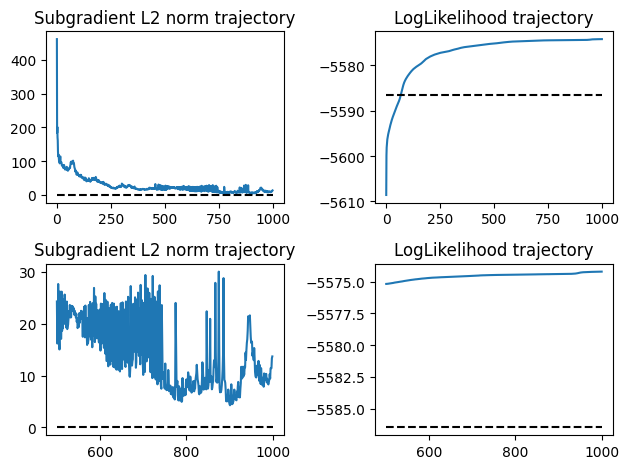

In [293]:
plt.figure()
plt.subplot(221)
plt.plot(np.arange(NITER), params['subgradient_l2_trajectory'])
plt.plot([0, NITER], [0, 0], 'k--')
plt.title('Subgradient L2 norm trajectory')


plt.subplot(222)
plt.plot(np.arange(NITER+1), params['loglik_trajectory'])
plt.plot([0, NITER+1], [true_logL, true_logL], 'k--')
plt.title('LogLikelihood trajectory')


plt.subplot(223)
plt.plot(np.arange(NITER//2, NITER), params['subgradient_l2_trajectory'][NITER//2:])
plt.plot([NITER//2, NITER], [0, 0], 'k--')
plt.title('Subgradient L2 norm trajectory')

plt.subplot(224)
plt.plot(np.arange(NITER//2, NITER+1), params['loglik_trajectory'][NITER//2:])
plt.plot([NITER//2, NITER+1], [true_logL, true_logL], 'k--')
plt.title('LogLikelihood trajectory')

plt.tight_layout()

In [294]:
params['substitution_matrix']

Array([[ 0.12543097, -0.18791023, -0.12881269,  0.00126995],
       [-0.14421037,  0.15315318, -0.10254885,  0.0027068 ],
       [-0.04884771, -0.0238058 ,  0.16523837, -0.04962225],
       [-0.04807805, -0.11328308, -0.02488581,  0.11739602]],
         alphabet='ACGT')

In [295]:
theta_final = np.concatenate([np.array(params['substitution_matrix']).flatten(), 
                                [params['open_gap_score'], 
                                params['extend_gap_score']]])

In [296]:
print('Baseline SE:', np.linalg.norm(theta_baseline - theta_star))
print('Final SE:', np.linalg.norm(theta_final - theta_star))

Baseline SE: 0.7225280067808264
Final SE: 0.5055778994193021


### Parameter Convergence Experiment


In [297]:
theta = params['theta_trajectory']
loglik = np.array(params['loglik_trajectory'])

# ||theta_n - theta*||
theta_diff = []
for theta_n in theta: 
    diff = np.linalg.norm(theta_n - theta_star)
    theta_diff.append(diff)

theta_diff = np.array(theta_diff)

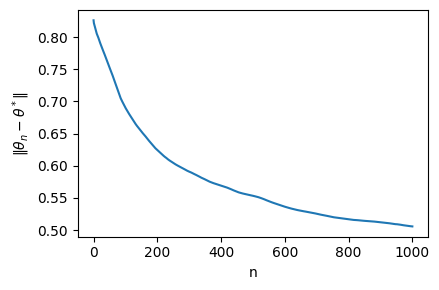

In [298]:
# ||theta_n - theta*|| vs n
plt.figure(figsize=FIGSIZE)

plt.plot(range(len(theta_diff)), theta_diff)

plt.xlabel("n")
plt.ylabel(r"$\|\theta_n - \theta^*\|$")

plt.tight_layout()
plt.show()

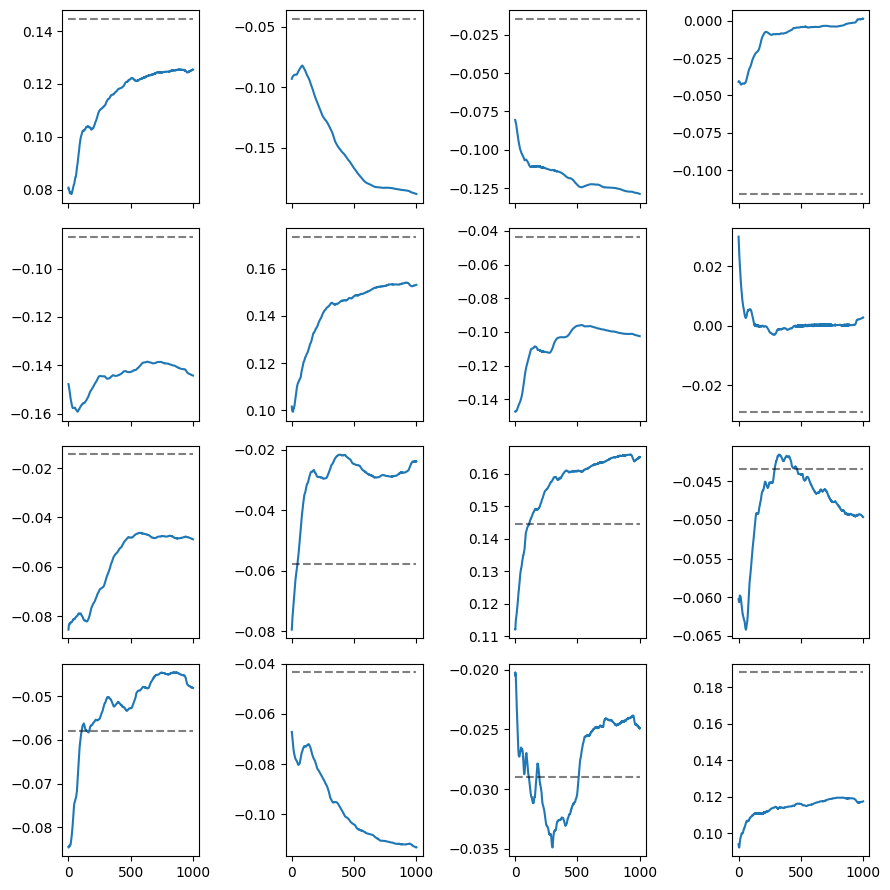

In [299]:
plt.subplots(4, 4, sharex=True, figsize=(9, 9))
for i in range(4):
    for j in range(4):
        plt.subplot(4, 4, 4*i + j + 1)
        plt.plot(range(NITER+1), theta[:, 4*i + j])
        plt.plot([0, NITER], [theta_star[4*i + j], theta_star[4*i + j]], 'k--', alpha=0.5)
plt.tight_layout()

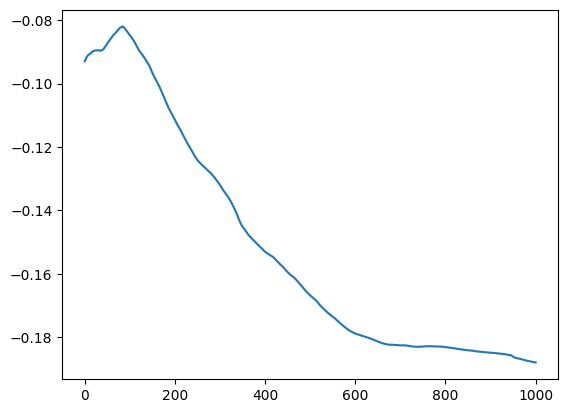

In [300]:
plt.figure()
plt.plot(range(NITER+1), theta[:, 1])

In [301]:
diff_array = np.zeros((len(theta_star), NITER+1))
for i, theta_n in enumerate(theta): 
    d = theta_star - theta_n 
    diff_array[..., i] = d

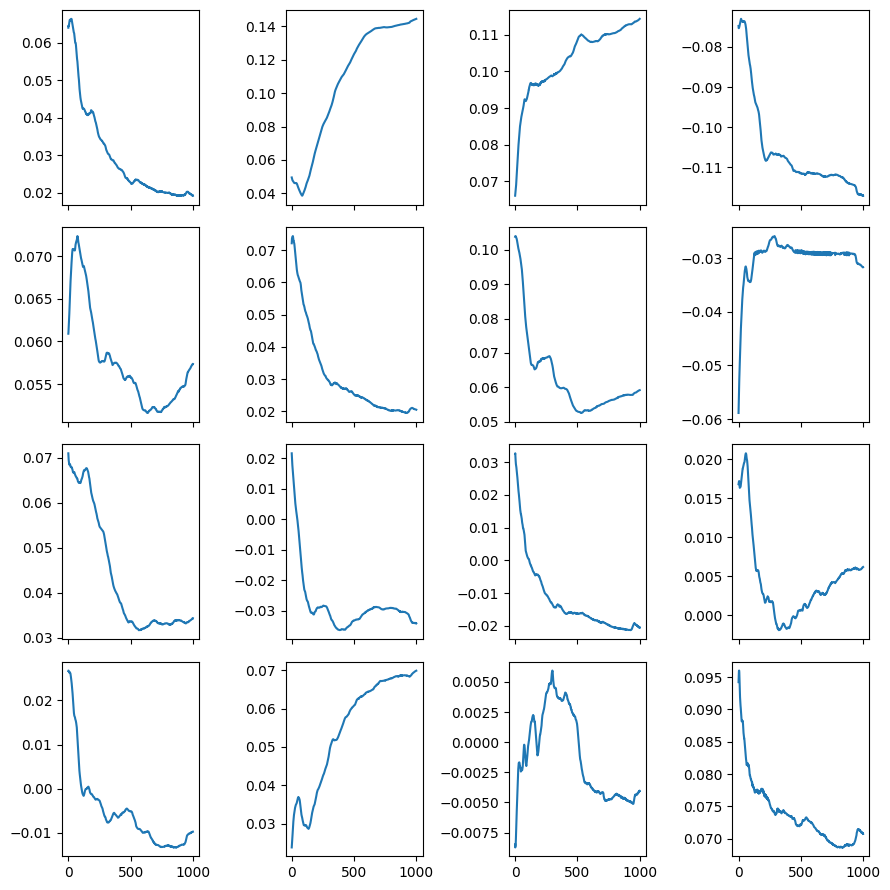

In [302]:
plt.subplots(4, 4, sharex=True, figsize=(9, 9))
for i in range(4):
    for j in range(4):
        plt.subplot(4, 4, 4*i + j + 1)
        plt.plot(range(NITER+1), diff_array[4*i + j, :])
plt.tight_layout()

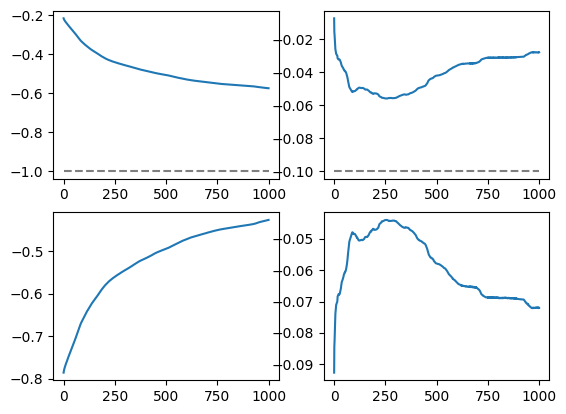

In [303]:
plt.figure()
plt.subplot(221)
plt.plot(range(NITER+1), theta[:,16])
plt.plot([0, NITER], [theta_star[16], theta_star[16]], 'k--', alpha=0.5)
plt.subplot(222)
plt.plot(range(NITER+1), theta[:,17])
plt.plot([0, NITER], [theta_star[17], theta_star[17]], 'k--', alpha=0.5)
plt.subplot(223)
plt.plot(range(NITER+1), diff_array[16])
plt.subplot(224)
plt.plot(range(NITER+1), diff_array[17])

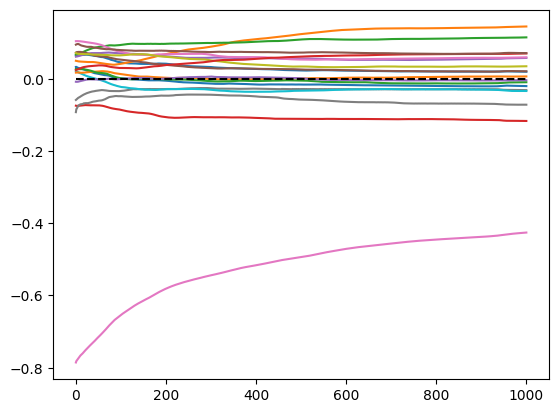

In [306]:
plt.figure()
for i in range(diff_array.shape[0]):
    plt.plot(range(NITER+1), diff_array[i])
plt.plot([0, NITER+1], [0,0], 'k--')

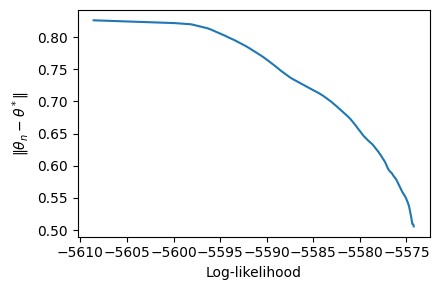

In [307]:
# ||theta_n - theta*|| vs log-likelihood

plt.figure(figsize=FIGSIZE)

plt.plot(loglik, theta_diff)

plt.xlabel("Log-likelihood")
plt.ylabel(r"$\|\theta_n - \theta^*\|$")

plt.tight_layout()
plt.show()

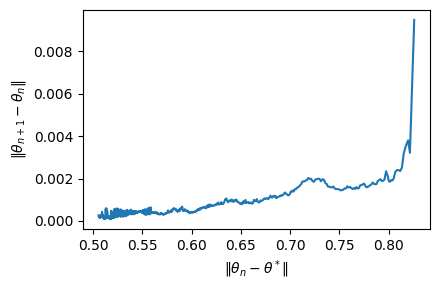

In [308]:
# ||theta_n - theta*|| vs ||theta_{n+1} - theta_n||
theta_nplusone = []
for n in range(len(theta) - 1):
    plusone = np.linalg.norm(theta[n+1] - theta[n])
    theta_nplusone.append(plusone)

theta_nplusone = np.array(theta_nplusone)

plt.figure(figsize=FIGSIZE)

plt.plot(theta_diff[:-1], theta_nplusone)

plt.ylabel(r"$\|\theta_{n+1} - \theta_n\|$")
plt.xlabel(r"$\|\theta_n - \theta^*\|$")

plt.tight_layout()
plt.show()

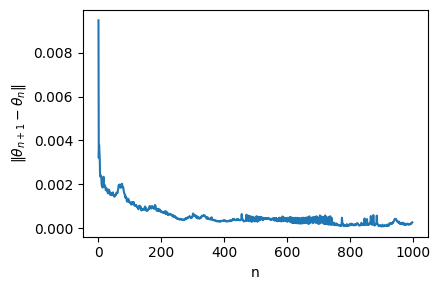

In [309]:
plt.figure(figsize=FIGSIZE)

plt.plot(range(NITER), theta_nplusone)

plt.xlabel('n')
plt.ylabel(r"$\|\theta_{n+1} - \theta_n\|$") 

plt.tight_layout()
plt.show()